Optimal K: 4
Silhouette Score: 0.4369

Cluster Profiles:
          Age  Annual_Income  Spending_Score
Cluster                                     
0        45.0          112.4            25.0
1        45.1           48.1            27.7
2        42.9           54.7            80.3
3        45.1          117.4            77.4


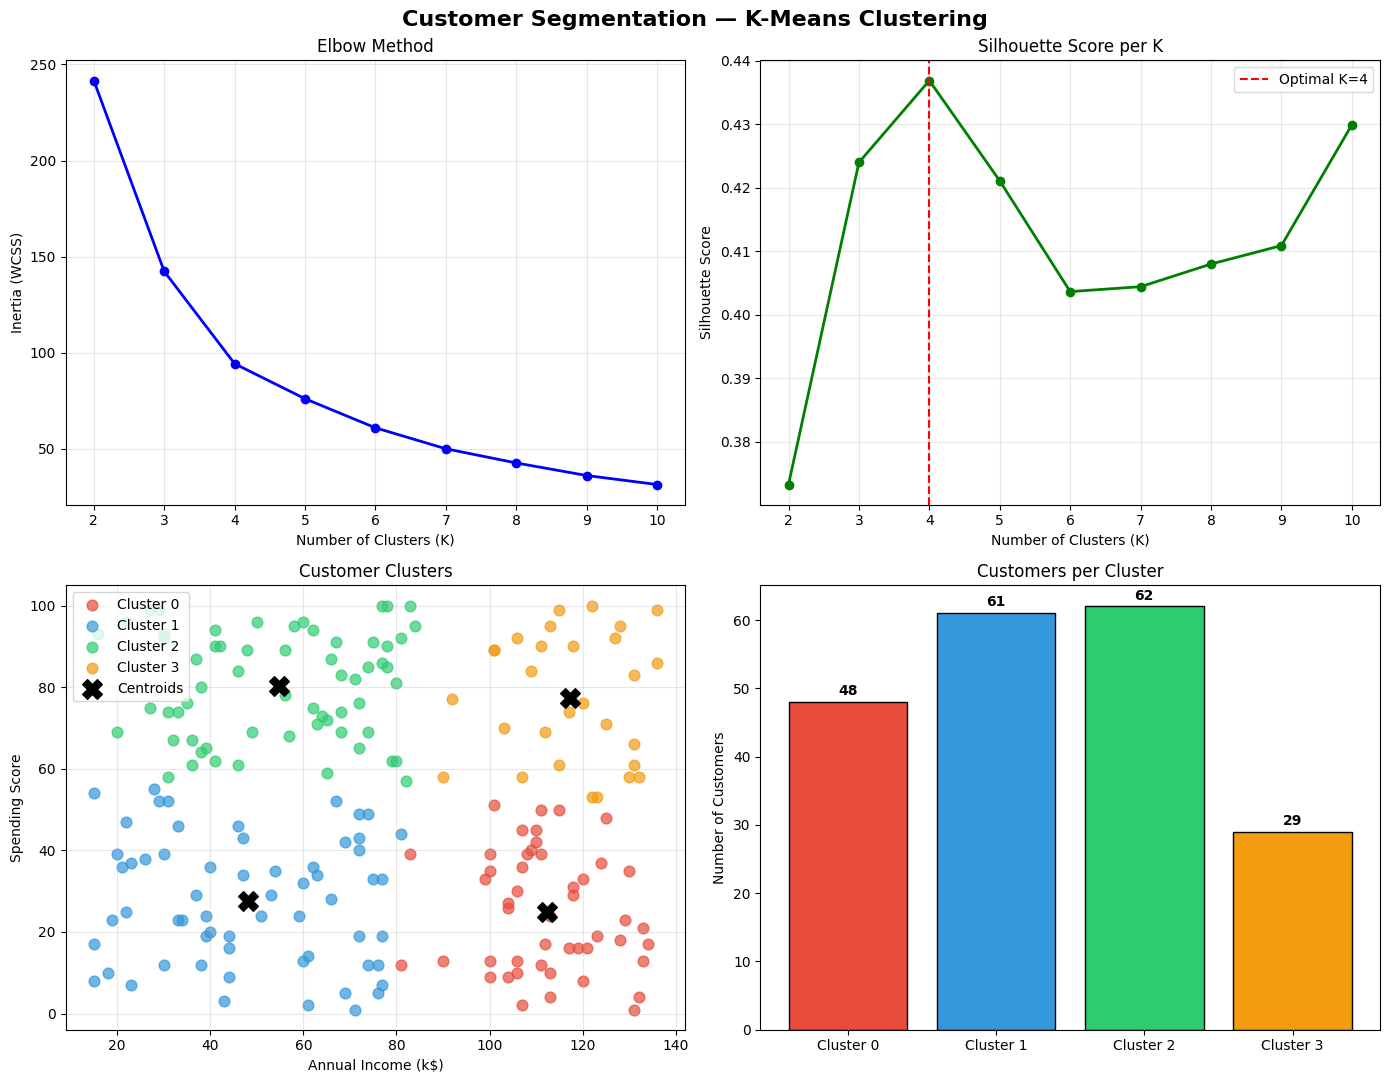

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. Generate Mall Customer Dataset
# ─────────────────────────────────────────────
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'CustomerID':     np.arange(1, n + 1),
    'Gender':         np.random.choice(['Male', 'Female'], n),
    'Age':            np.random.randint(18, 70, n),
    'Annual_Income':  np.random.randint(15, 137, n),       # in k$
    'Spending_Score': np.random.randint(1, 101, n)         # 1–100
})

# If using real dataset, replace above with:
# df = pd.read_csv('Mall_Customers.csv')

# ─────────────────────────────────────────────
# 2. Feature Selection & Scaling
# ─────────────────────────────────────────────
X = df[['Annual_Income', 'Spending_Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ─────────────────────────────────────────────
# 3. Elbow Method — Find Optimal K
# ─────────────────────────────────────────────
inertia    = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

optimal_k = K_range[np.argmax(sil_scores)]
print(f"Optimal K: {optimal_k}")

# ─────────────────────────────────────────────
# 4. Train Final K-Means Model
# ─────────────────────────────────────────────
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")

# ─────────────────────────────────────────────
# 5. Cluster Profiles
# ─────────────────────────────────────────────
print("\nCluster Profiles:")
print(df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1))

# ─────────────────────────────────────────────
# 6. Visualizations
# ─────────────────────────────────────────────
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Customer Segmentation — K-Means Clustering", fontsize=16, fontweight='bold')

# Plot 1: Elbow Curve
ax = axes[0, 0]
ax.plot(K_range, inertia, 'bo-', lw=2, markersize=6)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (WCSS)")
ax.set_title("Elbow Method")
ax.grid(True, alpha=0.3)

# Plot 2: Silhouette Scores
ax = axes[0, 1]
ax.plot(K_range, sil_scores, 'go-', lw=2, markersize=6)
ax.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score per K")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Clusters — Income vs Spending
ax = axes[1, 0]
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    ax.scatter(df.loc[mask, 'Annual_Income'],
               df.loc[mask, 'Spending_Score'],
               label=f'Cluster {c}', color=colors[c], alpha=0.7, s=60)
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centers_orig[:, 0], centers_orig[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score")
ax.set_title("Customer Clusters")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Cluster Size Bar Chart
ax = axes[1, 1]
cluster_counts = df['Cluster'].value_counts().sort_index()
bars = ax.bar(
    [f'Cluster {i}' for i in cluster_counts.index],
    cluster_counts.values,
    color=[colors[i] for i in cluster_counts.index],
    edgecolor='black'
)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, str(val), ha='center', fontweight='bold')
ax.set_ylabel("Number of Customers")
ax.set_title("Customers per Cluster")

plt.tight_layout()
plt.savefig('kmeans_customers.png', dpi=150, bbox_inches='tight')
plt.show()